In [6]:
%pip install netCDF4 h5netcdf

Note: you may need to restart the kernel to use updated packages.


Looking for NetCDF files in: /Users/edward/Desktop/Curriculum/EART60702/project_2
Found 6 file(s):
 - 003_2006_2080_352_360.nc
 - 004_2006_2080_352_360.nc
 - 005_2006_2080_352_360.nc
 - 006_2006_2080_352_360.nc
 - 007_2006_2080_352_360.nc
 - 008_2006_2080_352_360.nc

Loading 6 ensemble member(s)...

Loading member 003: 003_2006_2080_352_360.nc
Loaded 27,374 rows for member 003

Loading member 004: 004_2006_2080_352_360.nc
Loaded 27,374 rows for member 004

Loading member 005: 005_2006_2080_352_360.nc
Loaded 27,374 rows for member 005

Loading member 006: 006_2006_2080_352_360.nc
Loaded 27,374 rows for member 006

Loading member 007: 007_2006_2080_352_360.nc
Loaded 27,374 rows for member 007

Loading member 008: 008_2006_2080_352_360.nc
Loaded 27,374 rows for member 008

Loaded 164,244 rows total
Loaded 6 ensemble members
Years: 2006 to 2080

TREFMXAV_U summary (Celsius):

Overall:
count    164244.00
mean         15.75
std           5.23
min          -1.82
25%          11.67
50%        

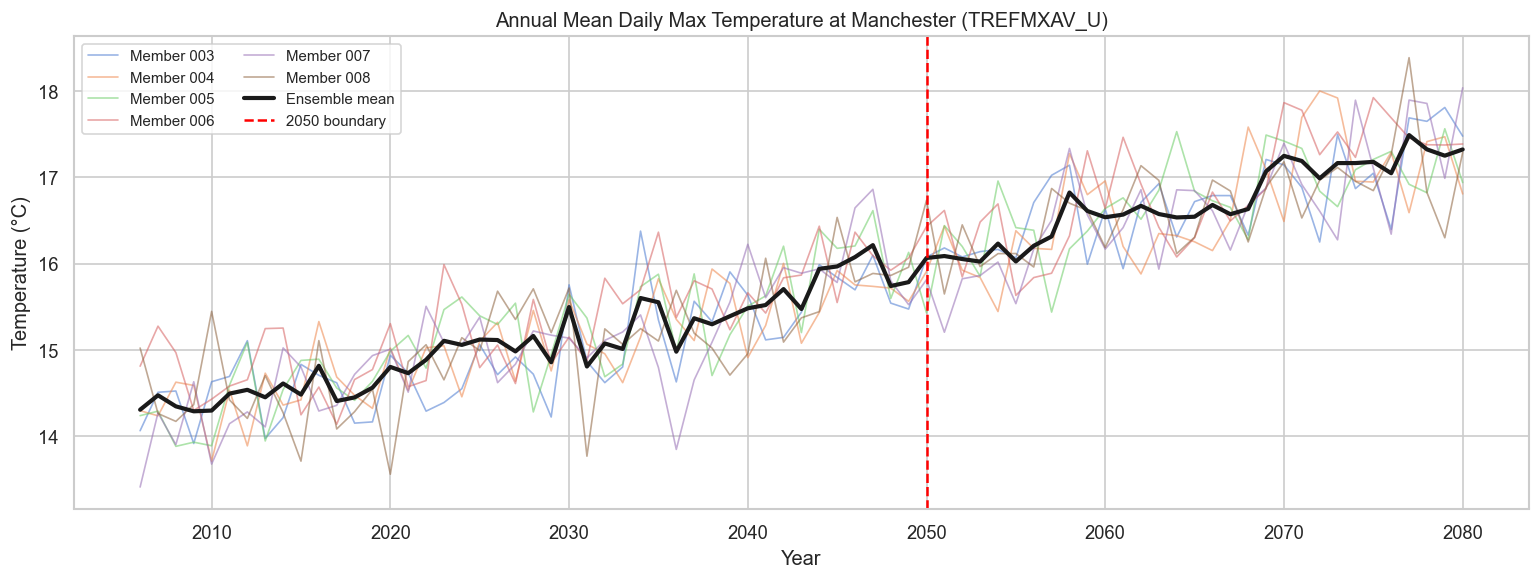

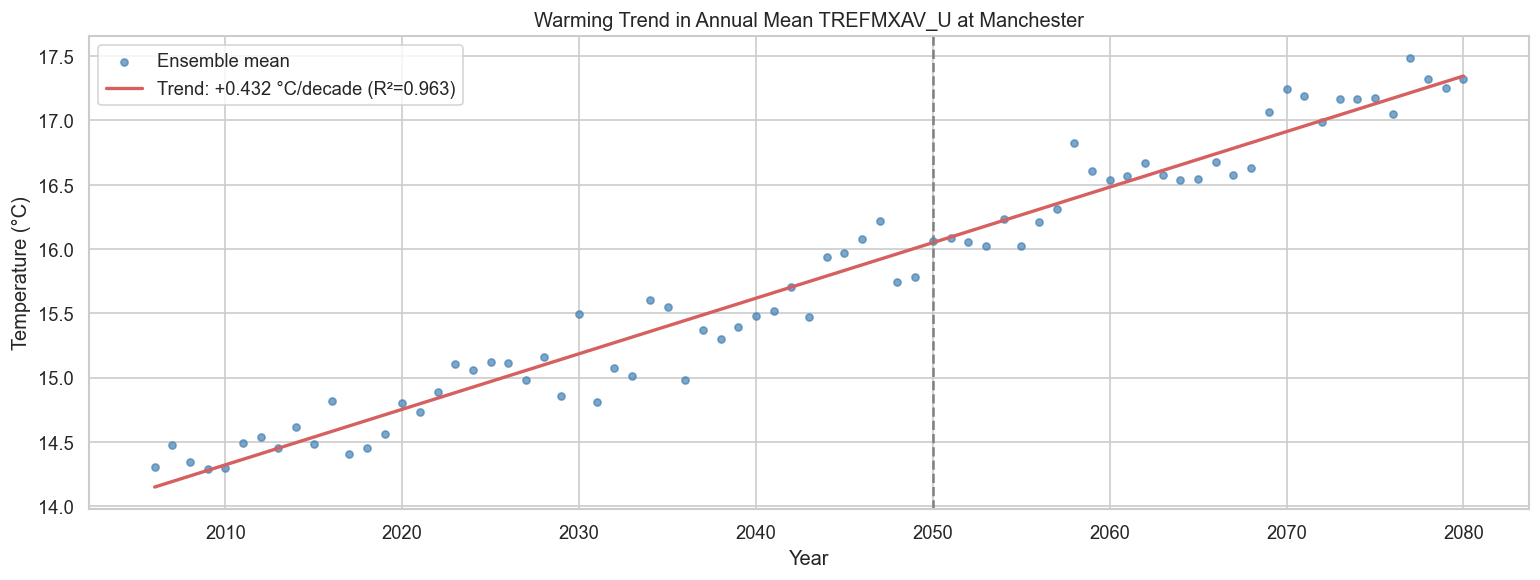

Trend: 0.0432 °C/year  (0.432 °C/decade)
Estimated warming 2006 to 2080: 3.20 °C


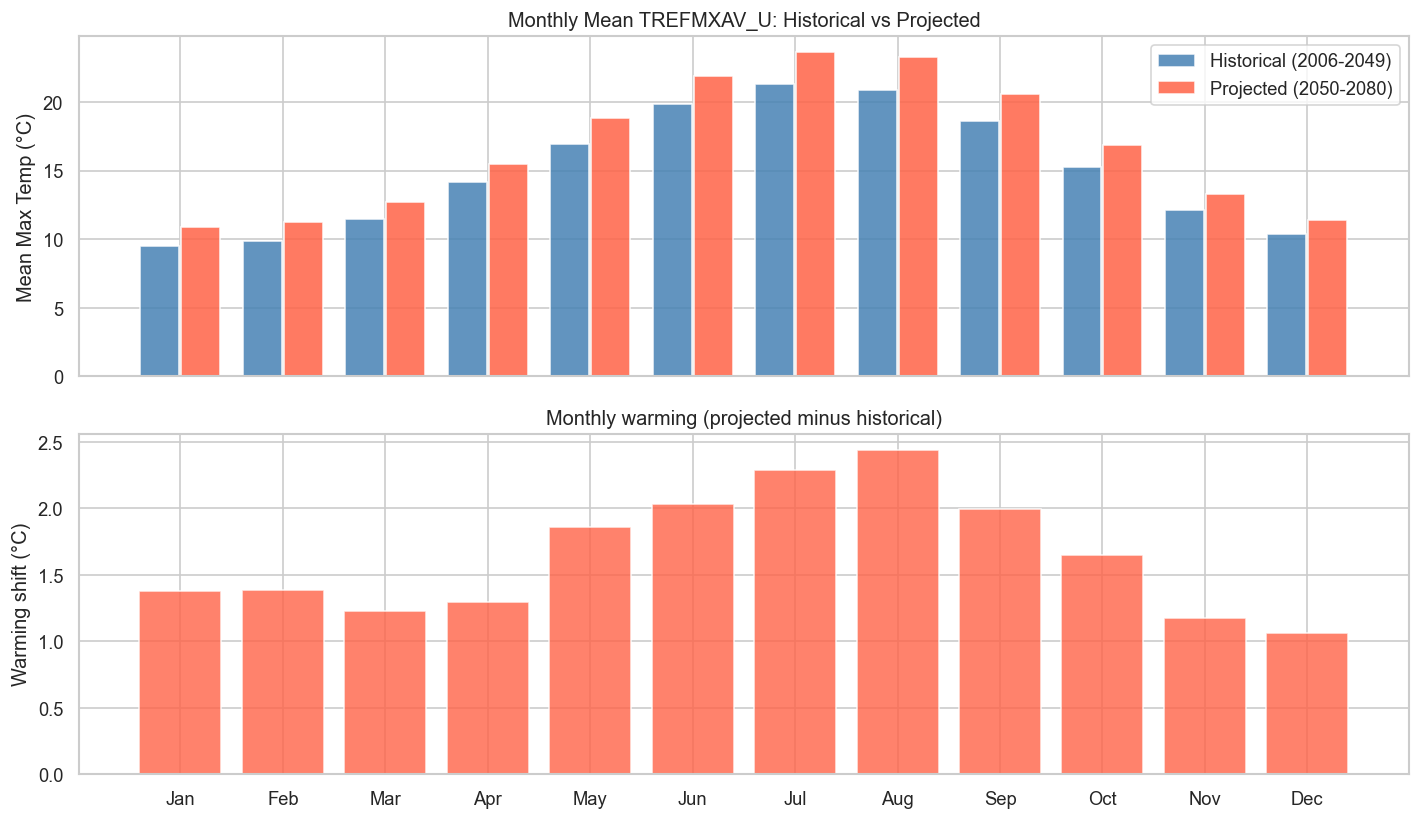


Monthly warming shifts:
  Jan: +1.38 °C
  Feb: +1.39 °C
  Mar: +1.23 °C
  Apr: +1.30 °C
  May: +1.86 °C
  Jun: +2.03 °C
  Jul: +2.29 °C
  Aug: +2.44 °C
  Sep: +2.00 °C
  Oct: +1.65 °C
  Nov: +1.17 °C
  Dec: +1.06 °C


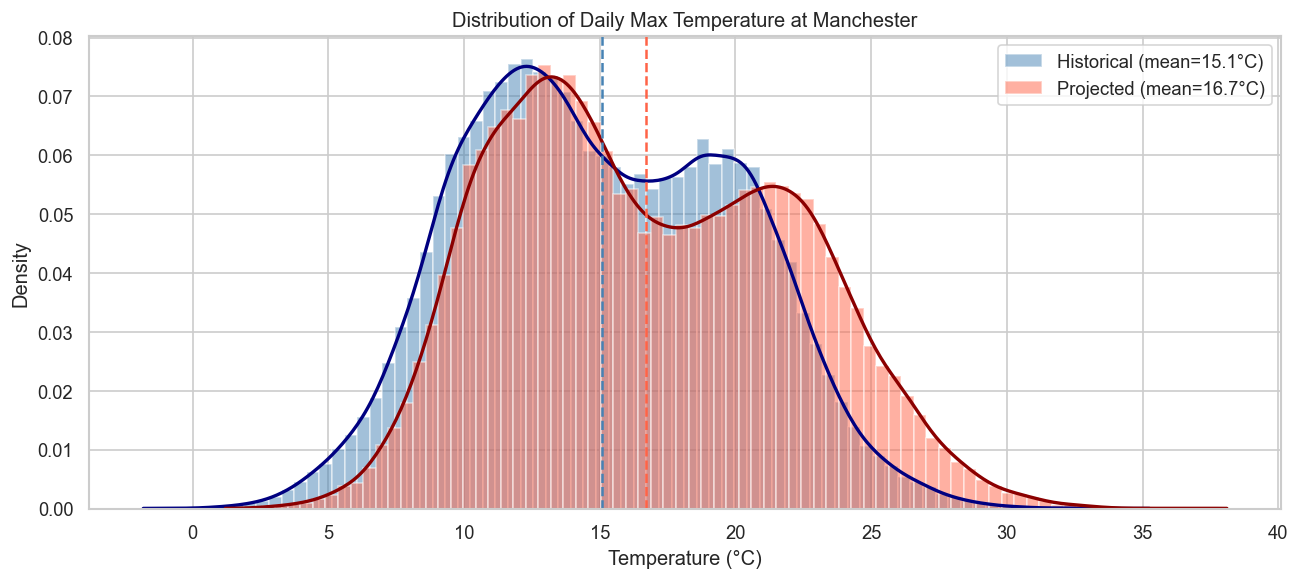

Mean shift: +1.65°C
Welch t-test: t=-62.86, p=0.00e+00  (significant: True)


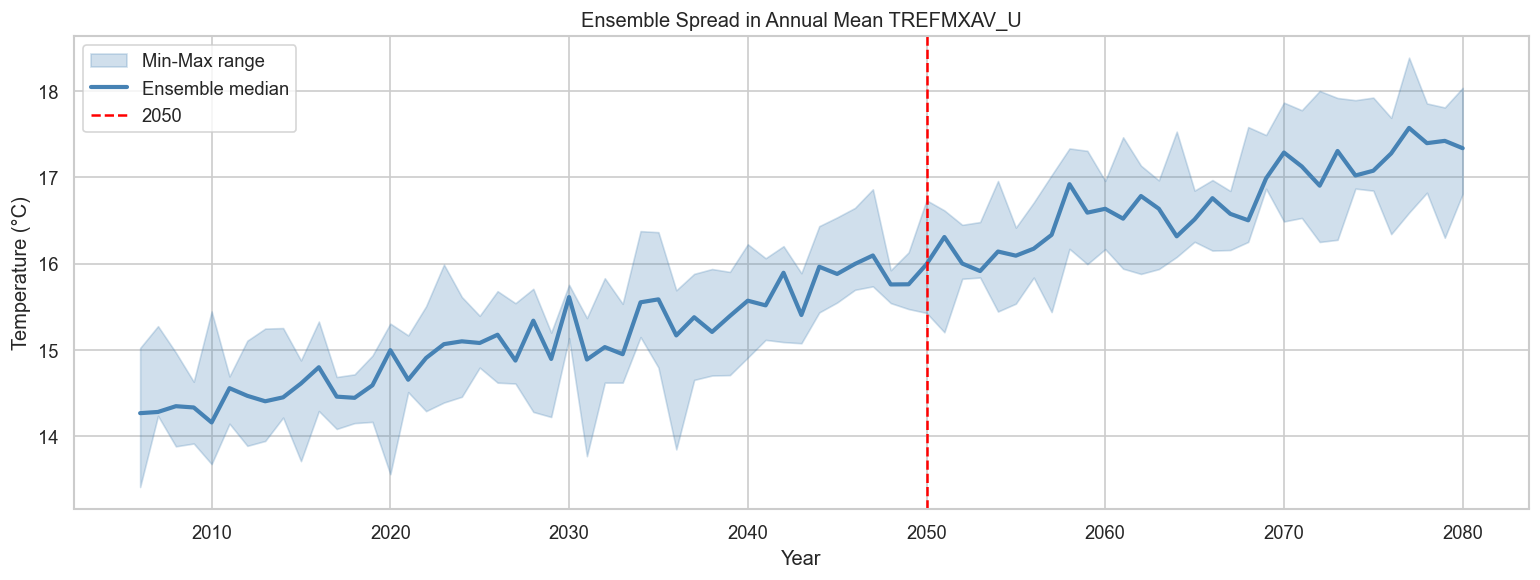

Spread in projected period: mean 1.17°C, max 1.79°C


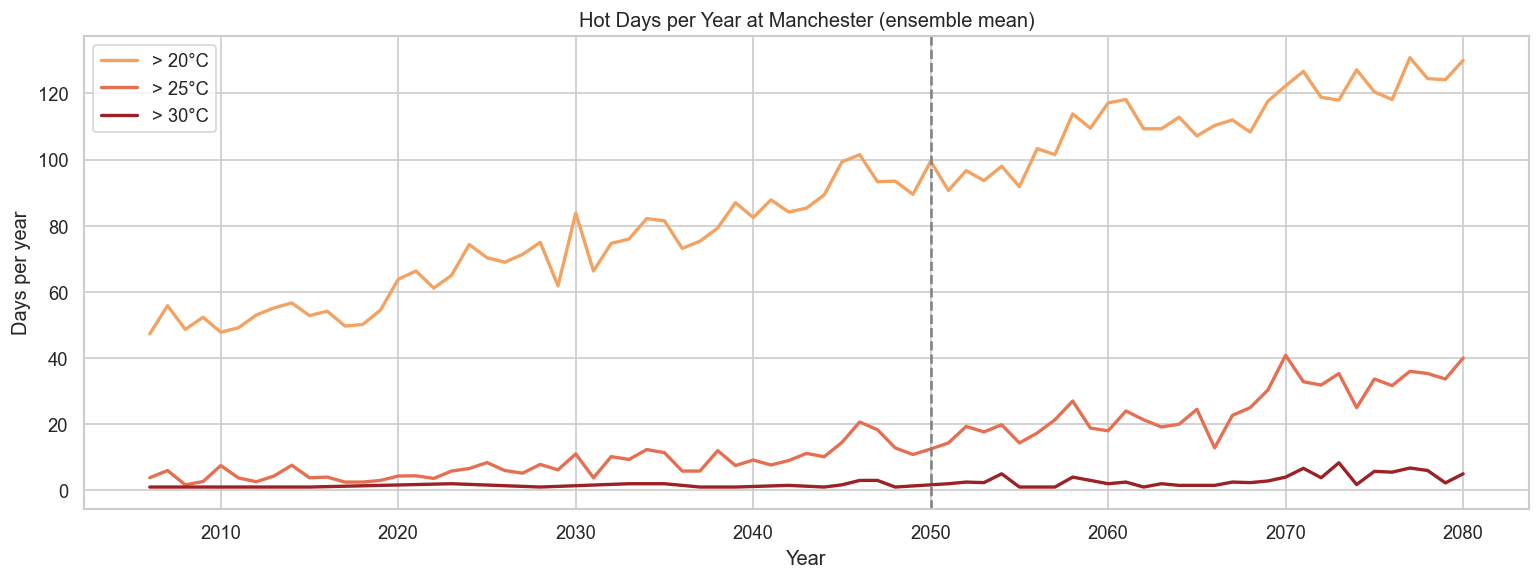


Hot days per year (ensemble mean):
  > 20°C:  hist=70.3/yr  proj=112.3/yr  change=+42.1
  > 25°C:  hist=7.7/yr  proj=25.0/yr  change=+17.3
  > 30°C:  hist=1.9/yr  proj=3.6/yr  change=+1.7


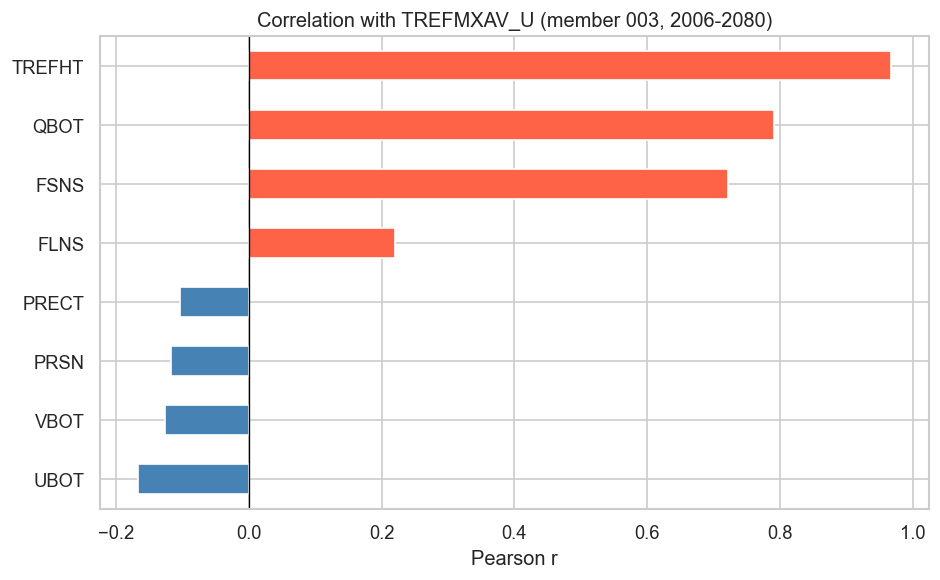


Correlations with TREFMXAV_U:
  TREFHT  : r = +0.9676
  QBOT    : r = +0.7916
  FSNS    : r = +0.7213
  FLNS    : r = +0.2197
  UBOT    : r = -0.1674
  VBOT    : r = -0.1264
  PRSN    : r = -0.1170
  PRECT   : r = -0.1038


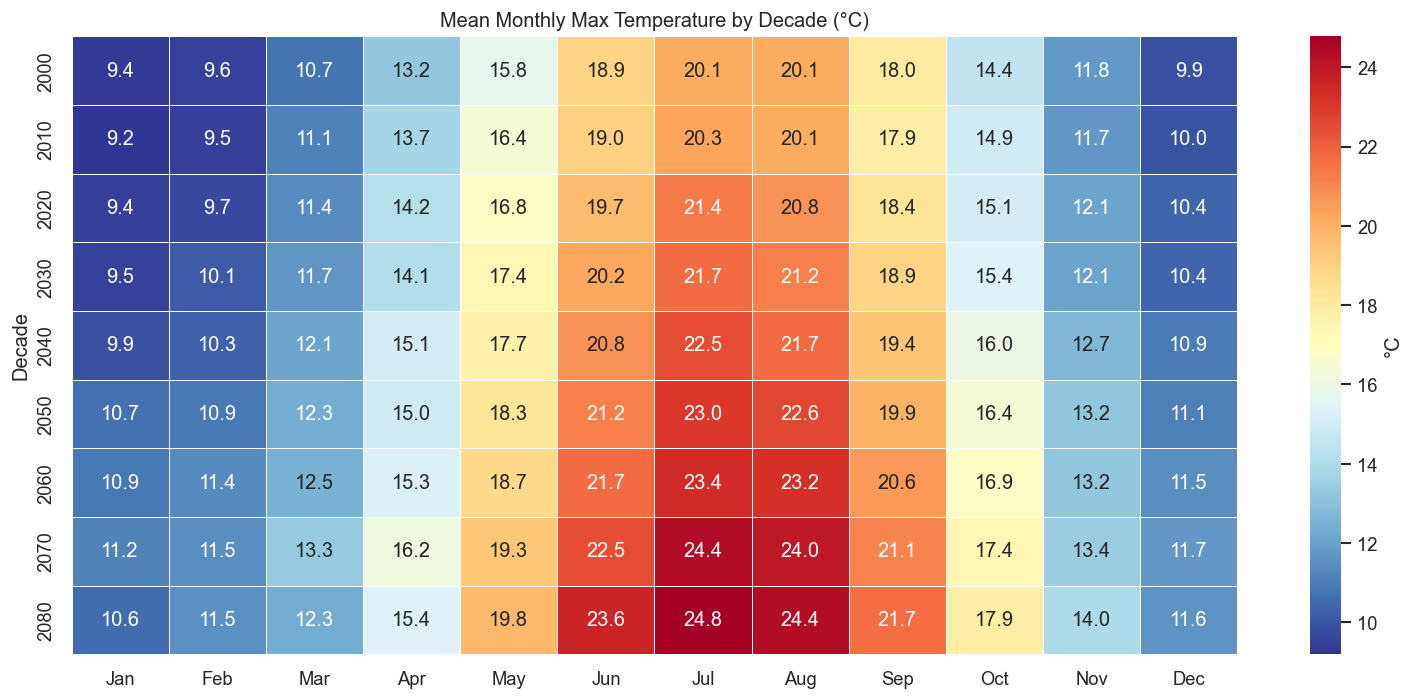


EDA done.


In [7]:
# %%
# 01_EDA.py
# Exploratory data analysis for TREFMXAV_U at Manchester
# CESM2 LENS2, ensemble members 003-008, 2006-2080

import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

# %%
# Find NetCDF files

DATA_DIR = "."
NC_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc*")))

print(f"Looking for NetCDF files in: {os.path.abspath(DATA_DIR)}")
print(f"Found {len(NC_FILES)} file(s):")
for f in NC_FILES:
    print(" -", os.path.basename(f))

if len(NC_FILES) == 0:
    raise FileNotFoundError(
        "No NetCDF files found in the current folder."
    )

MEMBER_IDS = [os.path.basename(f).split("_")[0] for f in NC_FILES]

# Manchester coords
MAN_LAT = 53.48
MAN_LON = 357.76

# %%
# Helper to open dataset with available engine

def open_nc_file(fpath):
    engines = ["netcdf4", "h5netcdf"]
    last_error = None

    for engine in engines:
        try:
            return xr.open_dataset(fpath, engine=engine, decode_times=True)
        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"Could not open {os.path.basename(fpath)} with netcdf4 or h5netcdf. "
        f"Last error: {last_error}"
    )

# %%
# Load all ensemble members and extract Manchester grid point

print(f"\nLoading {len(NC_FILES)} ensemble member(s)...")

frames = []

for mid, fpath in zip(MEMBER_IDS, NC_FILES):
    try:
        print(f"\nLoading member {mid}: {os.path.basename(fpath)}")

        ds = open_nc_file(fpath)

        # Check required coordinates/variables exist
        required_coords = ["lat", "lon", "time"]
        for c in required_coords:
            if c not in ds.coords and c not in ds.variables:
                raise ValueError(f"Missing required coordinate/variable: {c}")

        if "TREFMXAV_U" not in ds.variables:
            raise ValueError("Missing required variable: TREFMXAV_U")

        # Select nearest grid point to Manchester
        sel = ds.sel(lat=MAN_LAT, lon=MAN_LON, method="nearest")

        # Convert to dataframe
        df = sel.to_dataframe().reset_index()

        if df.empty:
            print(f"Skipping {mid}: dataframe is empty")
            ds.close()
            continue

        # Extract time parts
        df["year"] = [t.year for t in df["time"]]
        df["month"] = [t.month for t in df["time"]]
        df["doy"] = [t.timetuple().tm_yday for t in df["time"]]

        # Kelvin to Celsius
        df["TREFMXAV_U_C"] = df["TREFMXAV_U"] - 273.15

        if "TREFHT" in df.columns:
            df["TREFHT_C"] = df["TREFHT"] - 273.15

        df["member"] = mid

        frames.append(df)
        print(f"Loaded {len(df):,} rows for member {mid}")

        ds.close()

    except Exception as e:
        print(f"Error loading {os.path.basename(fpath)}: {e}")
        continue

if len(frames) == 0:
    raise ValueError(
        "No valid datasets were loaded. "
        "Install netCDF4/h5netcdf and check that files contain lat, lon, time, and TREFMXAV_U."
    )

data = pd.concat(frames, ignore_index=True)

print(f"\nLoaded {len(data):,} rows total")
print(f"Loaded {data['member'].nunique()} ensemble members")
print(f"Years: {data['year'].min()} to {data['year'].max()}")

# %%
# Basic summary stats

print("\nTREFMXAV_U summary (Celsius):\n")

print("Overall:")
print(data["TREFMXAV_U_C"].describe().round(2))

print("\nHistorical (2006-2049) vs Projected (2050-2080):")
summary = (
    data.assign(period=data["year"].map(lambda y: "2006-2049" if y <= 2049 else "2050-2080"))
    .groupby("period")["TREFMXAV_U_C"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
print(summary)

print("\nPer-member means in the projected period:")
print(
    data[data["year"] >= 2050]
    .groupby("member")["TREFMXAV_U_C"]
    .mean()
    .round(2)
)

# %%
# Annual mean time series

annual = (
    data.groupby(["member", "year"])["TREFMXAV_U_C"]
    .mean()
    .reset_index(name="ann_mean")
)
ens_mean = annual.groupby("year")["ann_mean"].mean()

fig, ax = plt.subplots(figsize=(13, 5))
for mid, grp in annual.groupby("member"):
    ax.plot(grp["year"], grp["ann_mean"], lw=1.0, alpha=0.55, label=f"Member {mid}")
ax.plot(ens_mean.index, ens_mean.values, "k-", lw=2.5, label="Ensemble mean")
ax.axvline(2050, color="red", ls="--", lw=1.5, label="2050 boundary")
ax.set_title("Annual Mean Daily Max Temperature at Manchester (TREFMXAV_U)")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("eda_01_annual_timeseries.png", dpi=150)
plt.show()

# %%
# Linear warming trend

slope, intercept, r, p, se = stats.linregress(ens_mean.index, ens_mean.values)
trend = slope * ens_mean.index + intercept

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(ens_mean.index, ens_mean.values, s=18, color="steelblue", alpha=0.7, label="Ensemble mean")
ax.plot(
    ens_mean.index,
    trend,
    "r-",
    lw=2,
    label=f"Trend: {slope*10:+.3f} °C/decade (R²={r**2:.3f})"
)
ax.axvline(2050, color="grey", ls="--", lw=1.5)
ax.set_title("Warming Trend in Annual Mean TREFMXAV_U at Manchester")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_02_warming_trend.png", dpi=150)
plt.show()

print(f"Trend: {slope:.4f} °C/year  ({slope*10:.3f} °C/decade)")
print(f"Estimated warming 2006 to 2080: {slope*(2080-2006):.2f} °C")

# %%
# Seasonal cycle

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

hist = data[data["year"] <= 2049]
proj = data[data["year"] >= 2050]

hist_monthly = hist.groupby("month")["TREFMXAV_U_C"].mean()
proj_monthly = proj.groupby("month")["TREFMXAV_U_C"].mean()
shift = proj_monthly - hist_monthly

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

x = np.arange(1, 13)
axes[0].bar(x - 0.2, hist_monthly, 0.38, label="Historical (2006-2049)", color="steelblue", alpha=0.85)
axes[0].bar(x + 0.2, proj_monthly, 0.38, label="Projected (2050-2080)", color="tomato", alpha=0.85)
axes[0].set_ylabel("Mean Max Temp (°C)")
axes[0].set_title("Monthly Mean TREFMXAV_U: Historical vs Projected")
axes[0].legend()

axes[1].bar(x, shift, color="tomato", alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Warming shift (°C)")
axes[1].set_title("Monthly warming (projected minus historical)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(MONTH_NAMES)

plt.tight_layout()
plt.savefig("eda_03_seasonal_cycle.png", dpi=150)
plt.show()

print("\nMonthly warming shifts:")
for m, name in enumerate(MONTH_NAMES, 1):
    print(f"  {name}: {shift[m]:+.2f} °C")

# %%
# Distribution comparison

hist_vals = hist["TREFMXAV_U_C"].dropna()
proj_vals = proj["TREFMXAV_U_C"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    hist_vals, bins=80, alpha=0.5, color="steelblue", density=True,
    label=f"Historical (mean={hist_vals.mean():.1f}°C)"
)
ax.hist(
    proj_vals, bins=80, alpha=0.5, color="tomato", density=True,
    label=f"Projected (mean={proj_vals.mean():.1f}°C)"
)

for vals, col in [(hist_vals, "navy"), (proj_vals, "darkred")]:
    kde = gaussian_kde(vals)
    xs = np.linspace(vals.min(), vals.max(), 400)
    ax.plot(xs, kde(xs), color=col, lw=2)

ax.axvline(hist_vals.mean(), color="steelblue", ls="--", lw=1.5)
ax.axvline(proj_vals.mean(), color="tomato", ls="--", lw=1.5)
ax.set_title("Distribution of Daily Max Temperature at Manchester")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("eda_04_distribution.png", dpi=150)
plt.show()

t_stat, p_val = stats.ttest_ind(hist_vals, proj_vals, equal_var=False)
print(f"Mean shift: {proj_vals.mean() - hist_vals.mean():+.2f}°C")
print(f"Welch t-test: t={t_stat:.2f}, p={p_val:.2e}  (significant: {p_val < 0.05})")

# %%
# Ensemble spread

ann_pivot = annual.pivot(index="year", columns="member", values="ann_mean")
ann_min = ann_pivot.min(axis=1)
ann_max = ann_pivot.max(axis=1)
ann_med = ann_pivot.median(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(ann_pivot.index, ann_min, ann_max, alpha=0.25, color="steelblue", label="Min-Max range")
ax.plot(ann_pivot.index, ann_med, color="steelblue", lw=2.5, label="Ensemble median")
ax.axvline(2050, color="red", ls="--", lw=1.5, label="2050")
ax.set_title("Ensemble Spread in Annual Mean TREFMXAV_U")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_05_ensemble_spread.png", dpi=150)
plt.show()

spread_proj = ann_max[ann_max.index >= 2050] - ann_min[ann_min.index >= 2050]
print(f"Spread in projected period: mean {spread_proj.mean():.2f}°C, max {spread_proj.max():.2f}°C")

# %%
# Hot days count

thresholds = [20, 25, 30]
colors = ["#f4a261", "#e76f51", "#9b2226"]

fig, ax = plt.subplots(figsize=(13, 5))
for thresh, col in zip(thresholds, colors):
    by_year = (
        data[data["TREFMXAV_U_C"] > thresh]
        .groupby(["member", "year"])
        .size()
        .groupby("year")
        .mean()
    )
    ax.plot(by_year.index, by_year.values, color=col, lw=2, label=f"> {thresh}°C")

ax.axvline(2050, color="grey", ls="--", lw=1.5)
ax.set_title("Hot Days per Year at Manchester (ensemble mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Days per year")
ax.legend()
plt.tight_layout()
plt.savefig("eda_06_hot_days.png", dpi=150)
plt.show()

print("\nHot days per year (ensemble mean):")
for thresh in thresholds:
    h = (
        data[(data["year"] <= 2049) & (data["TREFMXAV_U_C"] > thresh)]
        .groupby(["member", "year"])
        .size()
        .mean()
    )
    p = (
        data[(data["year"] >= 2050) & (data["TREFMXAV_U_C"] > thresh)]
        .groupby(["member", "year"])
        .size()
        .mean()
    )
    print(f"  > {thresh}°C:  hist={h:.1f}/yr  proj={p:.1f}/yr  change={p-h:+.1f}")

# %%
# Correlations

VARS = ["TREFHT", "FSNS", "QBOT", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]
member0 = data[data["member"] == MEMBER_IDS[0]].copy()

corrs = {}
for v in VARS:
    if v in member0.columns:
        r = np.corrcoef(member0["TREFMXAV_U_C"], member0[v])[0, 1]
        corrs[v] = round(r, 4)

if len(corrs) > 0:
    corr_df = pd.Series(corrs).sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))
    colors_bar = ["tomato" if v > 0 else "steelblue" for v in corr_df.values]
    corr_df.plot(kind="barh", ax=ax, color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"Correlation with TREFMXAV_U (member {MEMBER_IDS[0]}, 2006-2080)")
    ax.set_xlabel("Pearson r")
    plt.tight_layout()
    plt.savefig("eda_07_correlations.png", dpi=150)
    plt.show()

    print("\nCorrelations with TREFMXAV_U:")
    for v, r in sorted(corrs.items(), key=lambda x: -abs(x[1])):
        print(f"  {v:8s}: r = {r:+.4f}")
else:
    print("\nNo correlation variables found in dataset.")

# %%
# Decade x Month heatmap

data["decade"] = (data["year"] // 10) * 10
hmap = data.groupby(["decade", "month"])["TREFMXAV_U_C"].mean().unstack("month")
hmap.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    hmap,
    annot=True,
    fmt=".1f",
    cmap="RdYlBu_r",
    ax=ax,
    linewidths=0.4,
    cbar_kws={"label": "°C"}
)
ax.set_title("Mean Monthly Max Temperature by Decade (°C)")
ax.set_ylabel("Decade")
plt.tight_layout()
plt.savefig("eda_08_decade_heatmap.png", dpi=150)
plt.show()

print("\nEDA done.")


QBOT summary (g/kg):

Overall:
count    164244.000
mean          6.545
std           2.123
min           1.555
25%           4.879
50%           6.246
75%           7.988
max          18.279
Name: QBOT_gkg, dtype: float64

Historical (2006-2049) vs Projected (2050-2080):
            mean    std    min        max
period                                   
2006-2049  6.300  2.005  1.555  16.483000
2050-2080  6.894  2.234  1.807  18.278999

Per-member means in the projected period:
member
003    6.860
004    6.932
005    6.903
006    6.970
007    6.860
008    6.837
Name: QBOT_gkg, dtype: float32


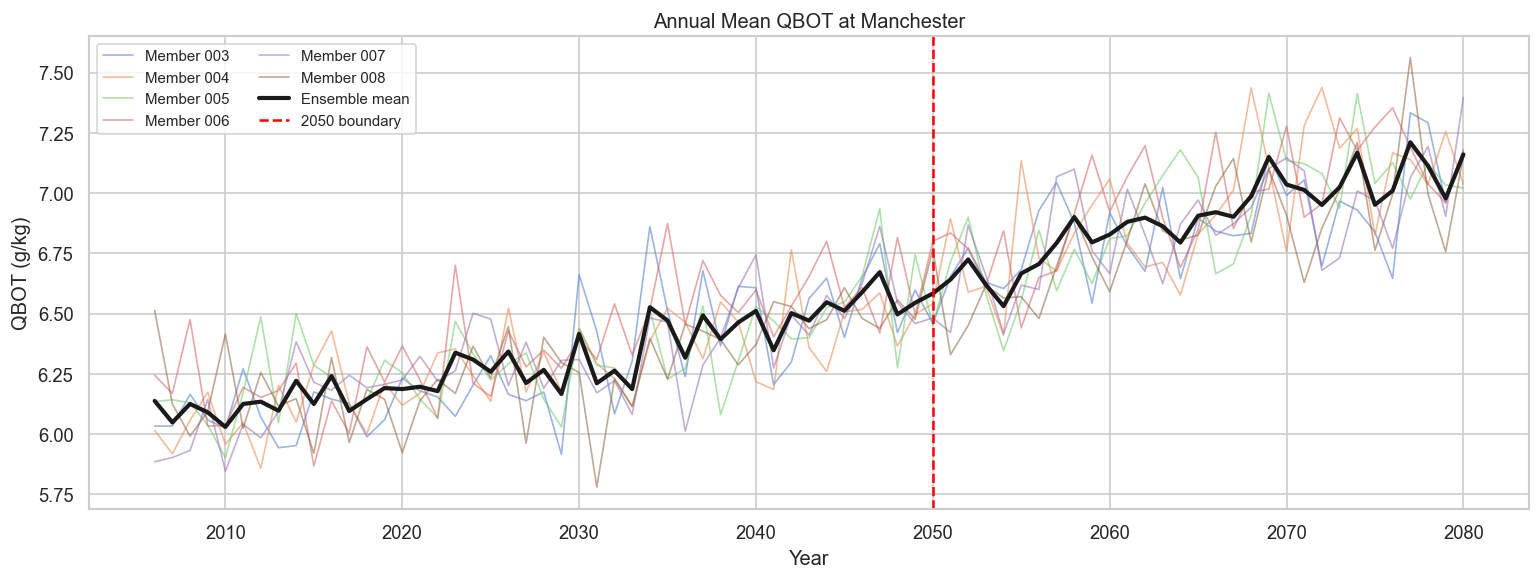

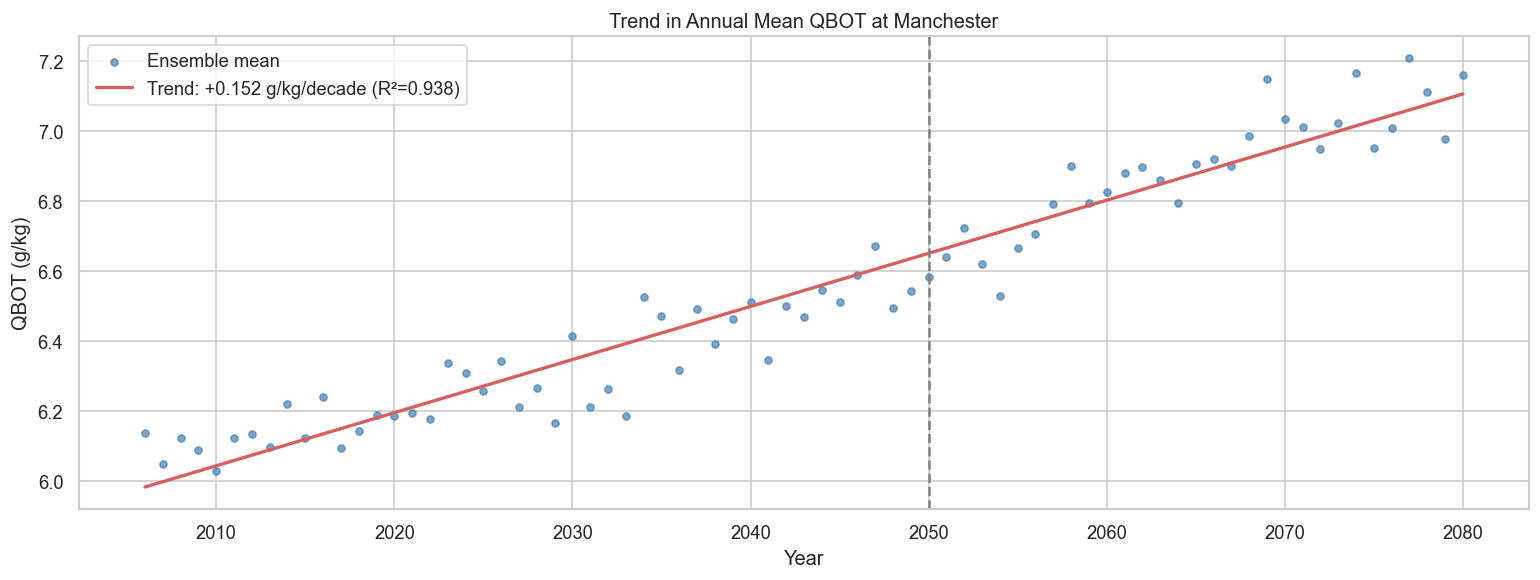

Trend: 0.0152 g/kg/year  (0.152 g/kg/decade)
Estimated change 2006 to 2080: 1.123 g/kg

QBOT mean moisture change:
  Historical mean: 6.300 g/kg
  Projected mean:  6.894 g/kg
  Absolute change: +0.594 g/kg
  Relative change: +9.42%


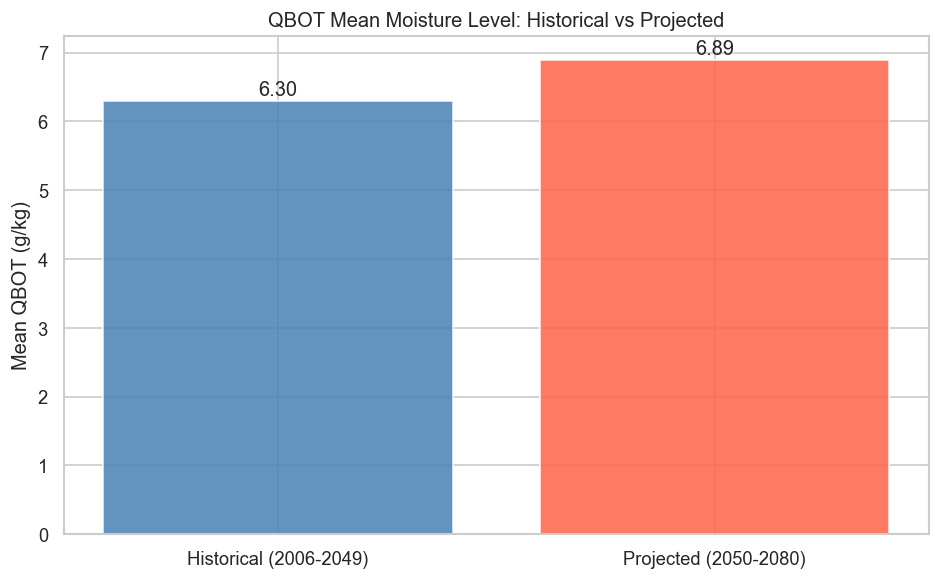

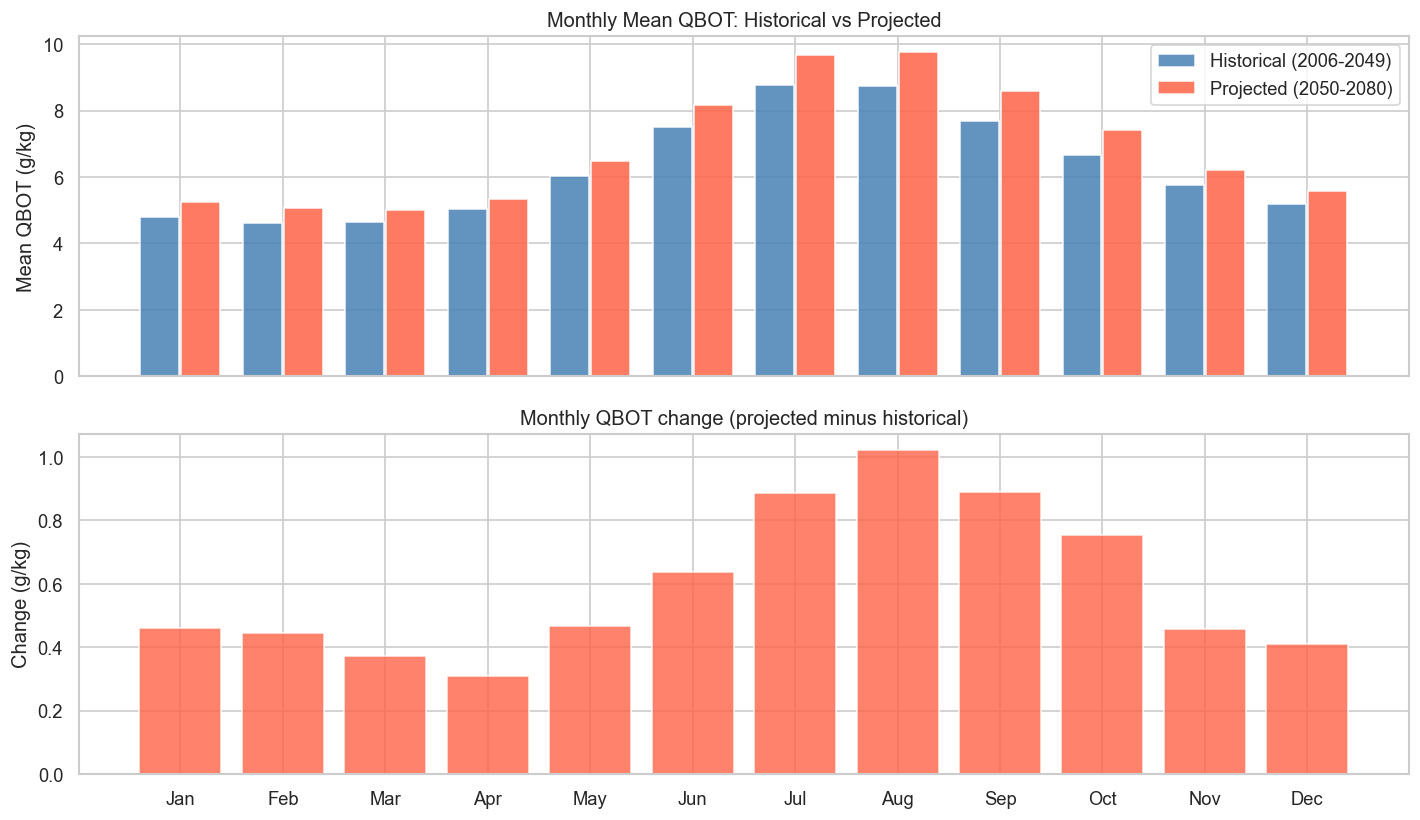


Monthly QBOT changes:
  Jan: +0.460 g/kg
  Feb: +0.445 g/kg
  Mar: +0.372 g/kg
  Apr: +0.311 g/kg
  May: +0.467 g/kg
  Jun: +0.637 g/kg
  Jul: +0.886 g/kg
  Aug: +1.021 g/kg
  Sep: +0.888 g/kg
  Oct: +0.753 g/kg
  Nov: +0.457 g/kg
  Dec: +0.411 g/kg

Warm-season (JJA) QBOT change:
  Historical JJA mean: 8.349 g/kg
  Projected JJA mean:  9.200 g/kg
  Absolute change:     +0.850 g/kg
  Relative change:     +10.19%


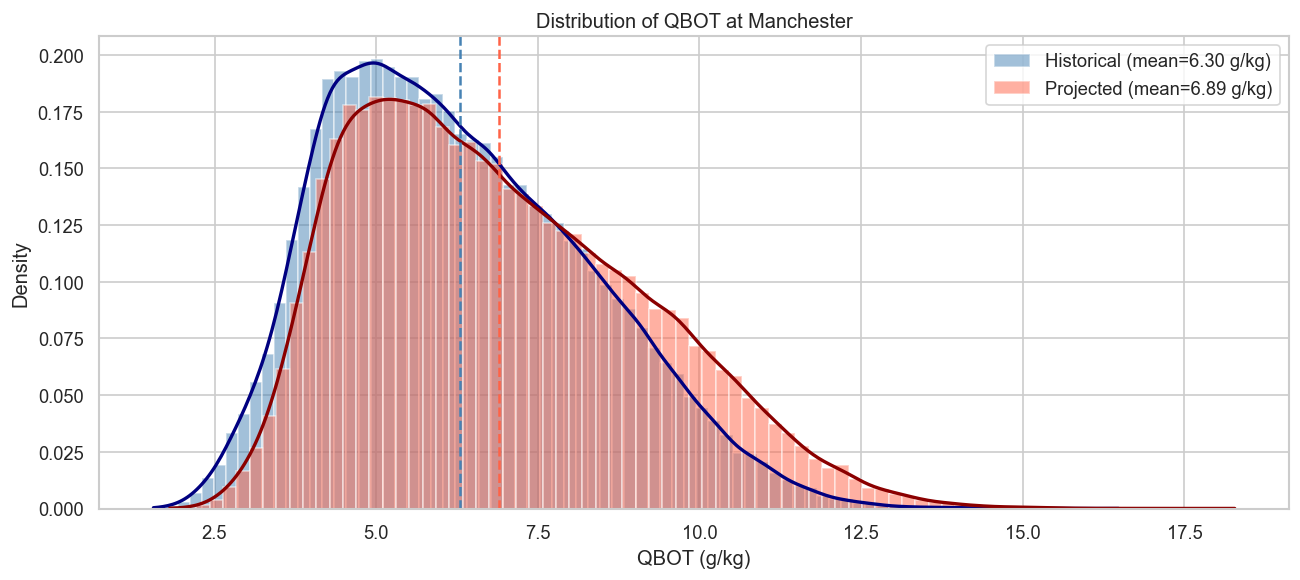

Mean shift: +0.594 g/kg
Welch t-test: t=-55.29, p=0.00e+00  (significant: True)


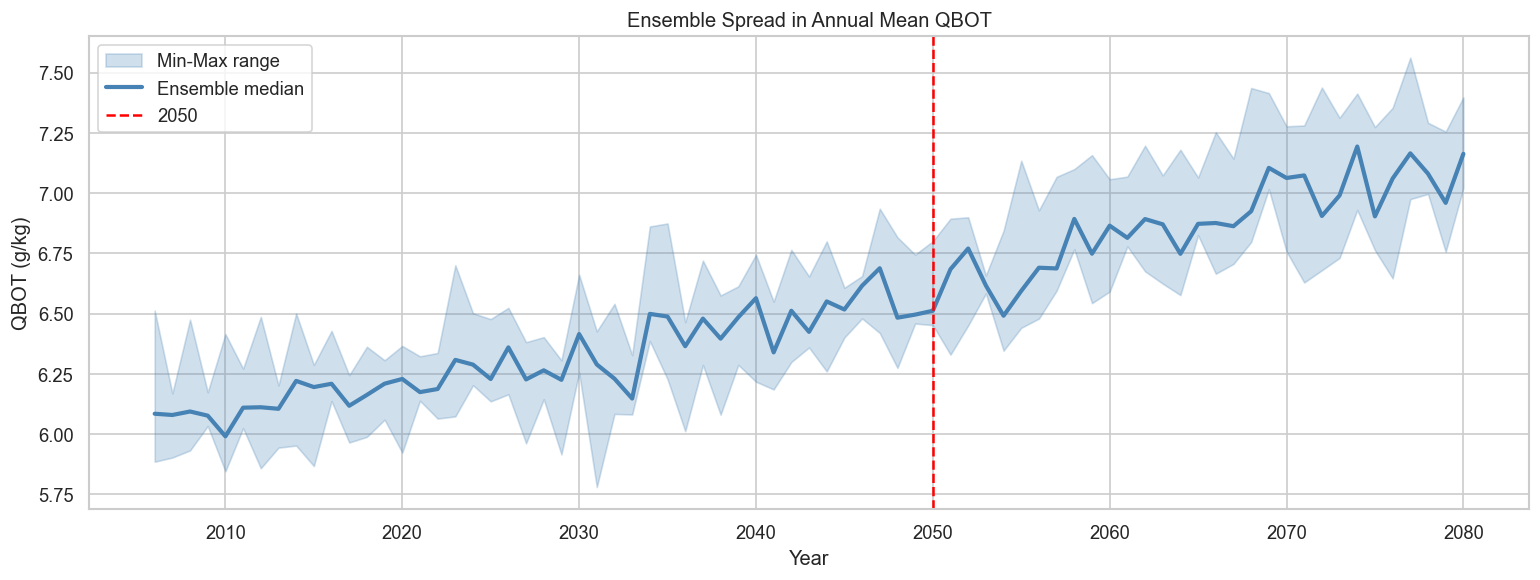

Spread in projected period: mean 0.487 g/kg, max 0.758 g/kg


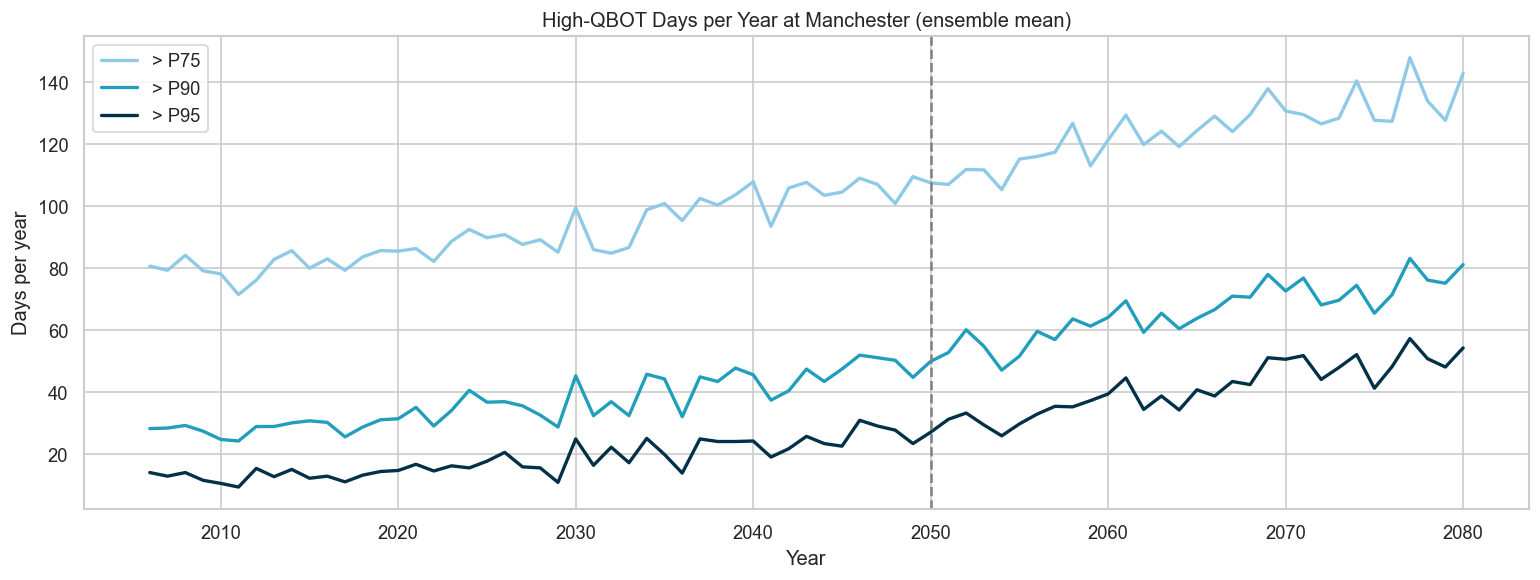


High-QBOT days per year (ensemble mean):
  > P75:  hist=91.2/yr  proj=124.3/yr  change=+33.0
  > P90:  hist=36.5/yr  proj=65.9/yr  change=+29.4
  > P95:  hist=18.2/yr  proj=41.1/yr  change=+22.9


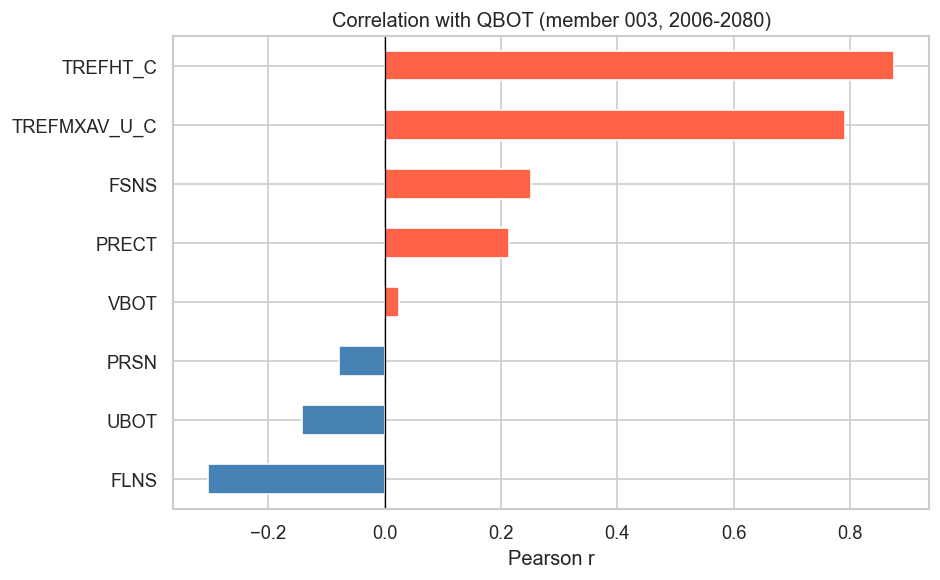


Correlations with QBOT:
  TREFHT_C    : r = +0.8762
  TREFMXAV_U_C: r = +0.7916
  FLNS        : r = -0.3045
  FSNS        : r = +0.2515
  PRECT       : r = +0.2136
  UBOT        : r = -0.1425
  PRSN        : r = -0.0780
  VBOT        : r = +0.0239


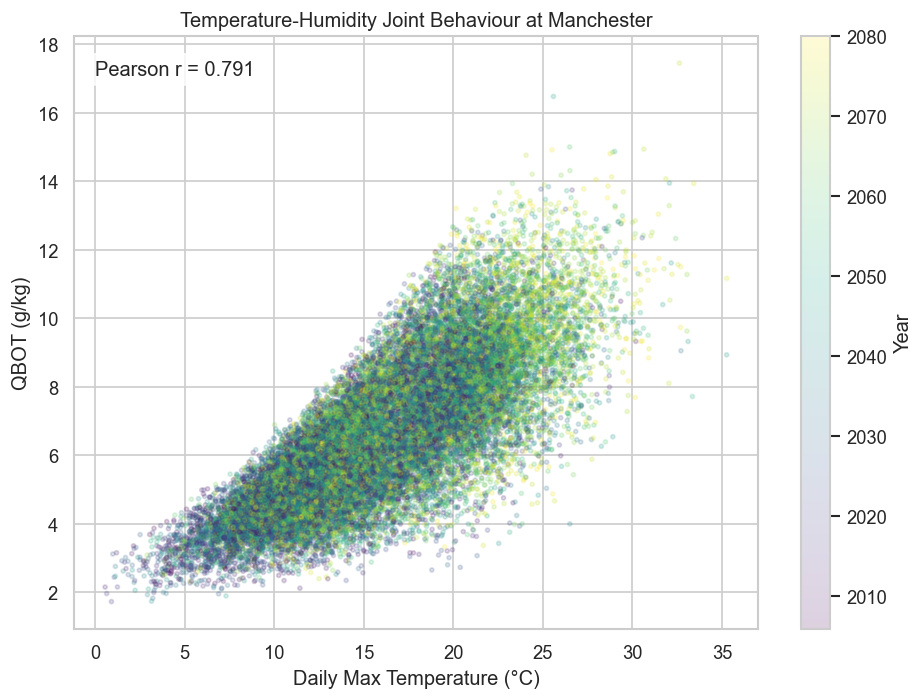

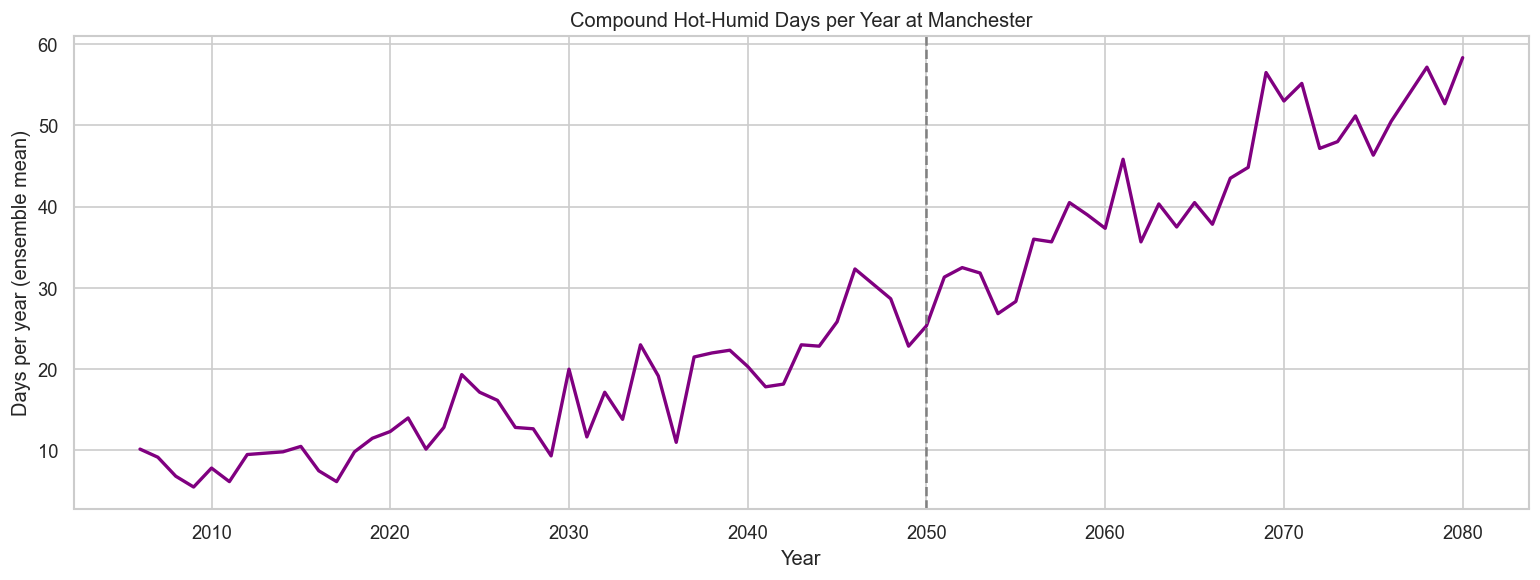


Compound hot-humid event diagnostics:
  Hot threshold (historical P90 Tmax):   21.71 °C
  Humid threshold (historical P90 QBOT): 9.119 g/kg
  Historical compound days: 15.48/yr
  Projected compound days:  42.60/yr
  Change:                   +27.12/yr


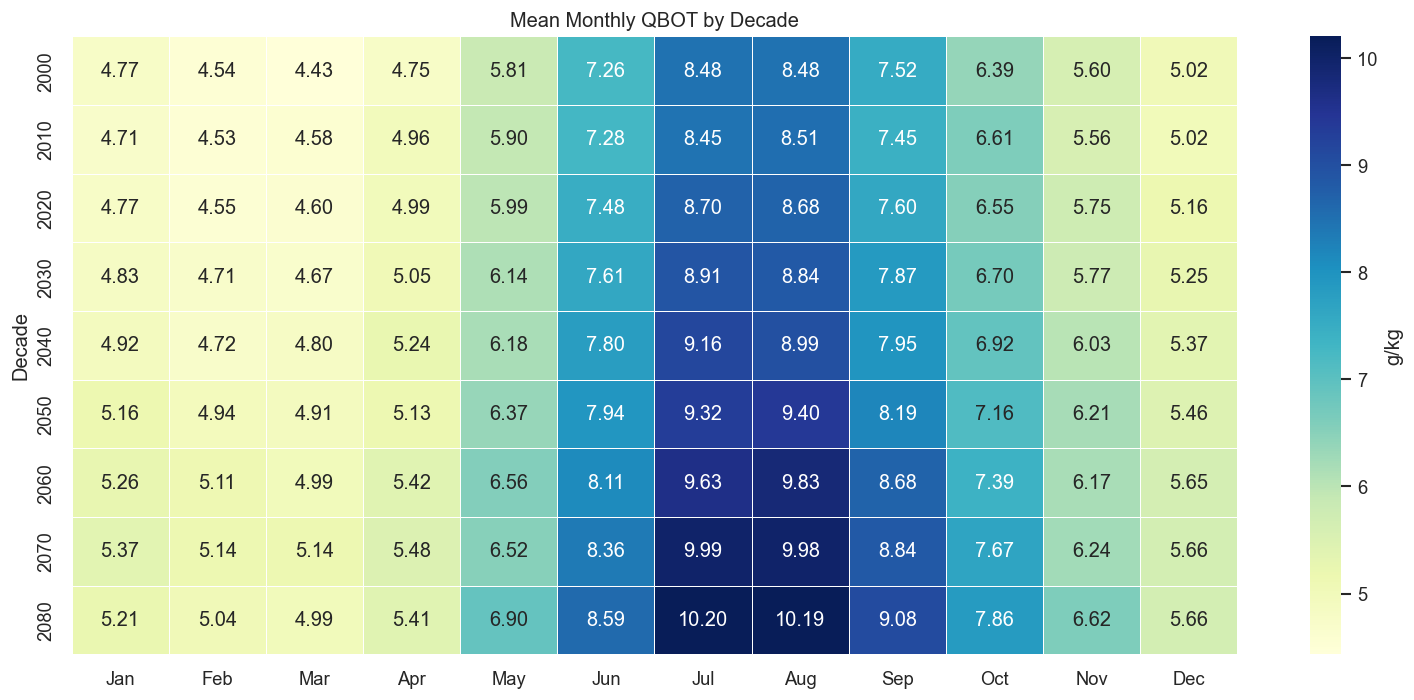


QBOT EDA done.


In [8]:
# %%
# 01B_QBOT_EDA.py
# Full EDA workflow for QBOT at Manchester
# Assumes the temperature/data-loading section has already created `data`.

if "QBOT" not in data.columns:
    raise ValueError("Missing required variable for QBOT EDA: QBOT")

if "QBOT_gkg" not in data.columns:
    data["QBOT_gkg"] = data["QBOT"] * 1000.0  # convert kg/kg to g/kg for readability

QBOT_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

qbot_hist = data[data["year"] <= 2049].copy()
qbot_proj = data[data["year"] >= 2050].copy()

# %%
# Basic summary stats

print("\nQBOT summary (g/kg):\n")

print("Overall:")
print(data["QBOT_gkg"].describe().round(3))

print("\nHistorical (2006-2049) vs Projected (2050-2080):")
qbot_summary = (
    data.assign(period=data["year"].map(lambda y: "2006-2049" if y <= 2049 else "2050-2080"))
    .groupby("period")["QBOT_gkg"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)
print(qbot_summary)

print("\nPer-member means in the projected period:")
print(
    data[data["year"] >= 2050]
    .groupby("member")["QBOT_gkg"]
    .mean()
    .round(3)
)

# %%
# Annual mean time series

qbot_annual = (
    data.groupby(["member", "year"])["QBOT_gkg"]
    .mean()
    .reset_index(name="ann_mean")
)
qbot_ens_mean = qbot_annual.groupby("year")["ann_mean"].mean()

fig, ax = plt.subplots(figsize=(13, 5))
for mid, grp in qbot_annual.groupby("member"):
    ax.plot(grp["year"], grp["ann_mean"], lw=1.0, alpha=0.55, label=f"Member {mid}")
ax.plot(qbot_ens_mean.index, qbot_ens_mean.values, "k-", lw=2.5, label="Ensemble mean")
ax.axvline(2050, color="red", ls="--", lw=1.5, label="2050 boundary")
ax.set_title("Annual Mean QBOT at Manchester")
ax.set_xlabel("Year")
ax.set_ylabel("QBOT (g/kg)")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("qbot_01_annual_timeseries.png", dpi=150)
plt.show()

# %%
# Linear trend

qbot_slope, qbot_intercept, qbot_r, qbot_p, qbot_se = stats.linregress(
    qbot_ens_mean.index, qbot_ens_mean.values
)
qbot_trend = qbot_slope * qbot_ens_mean.index + qbot_intercept

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(qbot_ens_mean.index, qbot_ens_mean.values, s=18, color="steelblue", alpha=0.7, label="Ensemble mean")
ax.plot(
    qbot_ens_mean.index,
    qbot_trend,
    "r-",
    lw=2,
    label=f"Trend: {qbot_slope*10:+.3f} g/kg/decade (R²={qbot_r**2:.3f})"
)
ax.axvline(2050, color="grey", ls="--", lw=1.5)
ax.set_title("Trend in Annual Mean QBOT at Manchester")
ax.set_xlabel("Year")
ax.set_ylabel("QBOT (g/kg)")
ax.legend()
plt.tight_layout()
plt.savefig("qbot_02_trend.png", dpi=150)
plt.show()

print(f"Trend: {qbot_slope:.4f} g/kg/year  ({qbot_slope*10:.3f} g/kg/decade)")
print(f"Estimated change 2006 to 2080: {qbot_slope*(2080-2006):.3f} g/kg")

# %%
# Historical vs projected mean change in readable units

qbot_hist_mean_gkg = qbot_hist["QBOT_gkg"].mean()
qbot_proj_mean_gkg = qbot_proj["QBOT_gkg"].mean()
qbot_abs_change_gkg = qbot_proj_mean_gkg - qbot_hist_mean_gkg
qbot_pct_change = 100 * qbot_abs_change_gkg / qbot_hist_mean_gkg

print("\nQBOT mean moisture change:")
print(f"  Historical mean: {qbot_hist_mean_gkg:.3f} g/kg")
print(f"  Projected mean:  {qbot_proj_mean_gkg:.3f} g/kg")
print(f"  Absolute change: {qbot_abs_change_gkg:+.3f} g/kg")
print(f"  Relative change: {qbot_pct_change:+.2f}%")

fig, ax = plt.subplots(figsize=(8, 5))
summary_df = pd.DataFrame(
    {
        "period": ["Historical (2006-2049)", "Projected (2050-2080)"],
        "mean_qbot_gkg": [qbot_hist_mean_gkg, qbot_proj_mean_gkg],
    }
)
ax.bar(summary_df["period"], summary_df["mean_qbot_gkg"], color=["steelblue", "tomato"], alpha=0.85)
ax.set_ylabel("Mean QBOT (g/kg)")
ax.set_title("QBOT Mean Moisture Level: Historical vs Projected")
for i, val in enumerate(summary_df["mean_qbot_gkg"]):
    ax.text(i, val + 0.02, f"{val:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("qbot_03_mean_change.png", dpi=150)
plt.show()

# %%
# Seasonal cycle

qbot_hist_monthly = qbot_hist.groupby("month")["QBOT_gkg"].mean()
qbot_proj_monthly = qbot_proj.groupby("month")["QBOT_gkg"].mean()
qbot_shift = qbot_proj_monthly - qbot_hist_monthly

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

x = np.arange(1, 13)
axes[0].bar(x - 0.2, qbot_hist_monthly, 0.38, label="Historical (2006-2049)", color="steelblue", alpha=0.85)
axes[0].bar(x + 0.2, qbot_proj_monthly, 0.38, label="Projected (2050-2080)", color="tomato", alpha=0.85)
axes[0].set_ylabel("Mean QBOT (g/kg)")
axes[0].set_title("Monthly Mean QBOT: Historical vs Projected")
axes[0].legend()

axes[1].bar(x, qbot_shift, color="tomato", alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Change (g/kg)")
axes[1].set_title("Monthly QBOT change (projected minus historical)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(QBOT_MONTH_NAMES)

plt.tight_layout()
plt.savefig("qbot_04_seasonal_cycle.png", dpi=150)
plt.show()

print("\nMonthly QBOT changes:")
for m, name in enumerate(QBOT_MONTH_NAMES, 1):
    print(f"  {name}: {qbot_shift[m]:+.3f} g/kg")

# %%
# Warm-season focus (JJA)

warm_months = [6, 7, 8]
qbot_hist_jja = qbot_hist[qbot_hist["month"].isin(warm_months)]["QBOT_gkg"]
qbot_proj_jja = qbot_proj[qbot_proj["month"].isin(warm_months)]["QBOT_gkg"]
qbot_jja_abs_change_gkg = qbot_proj_jja.mean() - qbot_hist_jja.mean()
qbot_jja_pct_change = 100 * qbot_jja_abs_change_gkg / qbot_hist_jja.mean()

print("\nWarm-season (JJA) QBOT change:")
print(f"  Historical JJA mean: {qbot_hist_jja.mean():.3f} g/kg")
print(f"  Projected JJA mean:  {qbot_proj_jja.mean():.3f} g/kg")
print(f"  Absolute change:     {qbot_jja_abs_change_gkg:+.3f} g/kg")
print(f"  Relative change:     {qbot_jja_pct_change:+.2f}%")

# %%
# Distribution comparison

qbot_hist_vals = qbot_hist["QBOT_gkg"].dropna()
qbot_proj_vals = qbot_proj["QBOT_gkg"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    qbot_hist_vals, bins=80, alpha=0.5, color="steelblue", density=True,
    label=f"Historical (mean={qbot_hist_vals.mean():.2f} g/kg)"
)
ax.hist(
    qbot_proj_vals, bins=80, alpha=0.5, color="tomato", density=True,
    label=f"Projected (mean={qbot_proj_vals.mean():.2f} g/kg)"
)

for vals, col in [(qbot_hist_vals, "navy"), (qbot_proj_vals, "darkred")]:
    kde = gaussian_kde(vals)
    xs = np.linspace(vals.min(), vals.max(), 400)
    ax.plot(xs, kde(xs), color=col, lw=2)

ax.axvline(qbot_hist_vals.mean(), color="steelblue", ls="--", lw=1.5)
ax.axvline(qbot_proj_vals.mean(), color="tomato", ls="--", lw=1.5)
ax.set_title("Distribution of QBOT at Manchester")
ax.set_xlabel("QBOT (g/kg)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("qbot_05_distribution.png", dpi=150)
plt.show()

qbot_t_stat, qbot_p_val = stats.ttest_ind(qbot_hist_vals, qbot_proj_vals, equal_var=False)
print(f"Mean shift: {qbot_proj_vals.mean() - qbot_hist_vals.mean():+.3f} g/kg")
print(f"Welch t-test: t={qbot_t_stat:.2f}, p={qbot_p_val:.2e}  (significant: {qbot_p_val < 0.05})")

# %%
# Ensemble spread

qbot_ann_pivot = qbot_annual.pivot(index="year", columns="member", values="ann_mean")
qbot_ann_min = qbot_ann_pivot.min(axis=1)
qbot_ann_max = qbot_ann_pivot.max(axis=1)
qbot_ann_med = qbot_ann_pivot.median(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(qbot_ann_pivot.index, qbot_ann_min, qbot_ann_max, alpha=0.25, color="steelblue", label="Min-Max range")
ax.plot(qbot_ann_pivot.index, qbot_ann_med, color="steelblue", lw=2.5, label="Ensemble median")
ax.axvline(2050, color="red", ls="--", lw=1.5, label="2050")
ax.set_title("Ensemble Spread in Annual Mean QBOT")
ax.set_xlabel("Year")
ax.set_ylabel("QBOT (g/kg)")
ax.legend()
plt.tight_layout()
plt.savefig("qbot_06_ensemble_spread.png", dpi=150)
plt.show()

qbot_spread_proj = qbot_ann_max[qbot_ann_max.index >= 2050] - qbot_ann_min[qbot_ann_min.index >= 2050]
print(f"Spread in projected period: mean {qbot_spread_proj.mean():.3f} g/kg, max {qbot_spread_proj.max():.3f} g/kg")

# %%
# High-QBOT days count using historical quantile thresholds

qbot_thresholds = {
    "P75": qbot_hist["QBOT_gkg"].quantile(0.75),
    "P90": qbot_hist["QBOT_gkg"].quantile(0.90),
    "P95": qbot_hist["QBOT_gkg"].quantile(0.95),
}
qbot_colors = ["#8ecae6", "#219ebc", "#023047"]

fig, ax = plt.subplots(figsize=(13, 5))
for (label, thresh), col in zip(qbot_thresholds.items(), qbot_colors):
    qbot_event_mask = data["QBOT_gkg"] > thresh
    qbot_counts = (
        data.assign(qbot_event=qbot_event_mask.astype(int))
        .groupby(["member", "year"])["qbot_event"]
        .sum()
        .reset_index(name="high_qbot_days")
    )
    by_year = qbot_counts.groupby("year")["high_qbot_days"].mean()
    ax.plot(by_year.index, by_year.values, color=col, lw=2, label=f"> {label}")

ax.axvline(2050, color="grey", ls="--", lw=1.5)
ax.set_title("High-QBOT Days per Year at Manchester (ensemble mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Days per year")
ax.legend()
plt.tight_layout()
plt.savefig("qbot_07_high_qbot_days.png", dpi=150)
plt.show()

print("\nHigh-QBOT days per year (ensemble mean):")
for label, thresh in qbot_thresholds.items():
    qbot_event_mask = data["QBOT_gkg"] > thresh
    qbot_counts = (
        data.assign(qbot_event=qbot_event_mask.astype(int))
        .groupby(["member", "year"])["qbot_event"]
        .sum()
        .reset_index(name="high_qbot_days")
    )
    h = qbot_counts[qbot_counts["year"] <= 2049]["high_qbot_days"].mean()
    p = qbot_counts[qbot_counts["year"] >= 2050]["high_qbot_days"].mean()
    print(f"  > {label}:  hist={h:.1f}/yr  proj={p:.1f}/yr  change={p-h:+.1f}")

# %%
# Correlations

qbot_corr_vars = ["TREFMXAV_U_C", "FSNS", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]
if "TREFHT_C" in data.columns:
    qbot_corr_vars.insert(1, "TREFHT_C")
elif "TREFHT" in data.columns:
    qbot_corr_vars.insert(1, "TREFHT")

qbot_member0 = data[data["member"] == MEMBER_IDS[0]].copy()

qbot_corrs = {}
for v in qbot_corr_vars:
    if v in qbot_member0.columns:
        r = np.corrcoef(qbot_member0["QBOT_gkg"], qbot_member0[v])[0, 1]
        qbot_corrs[v] = round(r, 4)

if len(qbot_corrs) > 0:
    qbot_corr_df = pd.Series(qbot_corrs).sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))
    qbot_colors_bar = ["tomato" if v > 0 else "steelblue" for v in qbot_corr_df.values]
    qbot_corr_df.plot(kind="barh", ax=ax, color=qbot_colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"Correlation with QBOT (member {MEMBER_IDS[0]}, 2006-2080)")
    ax.set_xlabel("Pearson r")
    plt.tight_layout()
    plt.savefig("qbot_08_correlations.png", dpi=150)
    plt.show()

    print("\nCorrelations with QBOT:")
    for v, r in sorted(qbot_corrs.items(), key=lambda x: -abs(x[1])):
        print(f"  {v:12s}: r = {r:+.4f}")
else:
    print("\nNo correlation variables found for QBOT.")

# %%
# Temperature-humidity joint behaviour

if "TREFMXAV_U_C" in data.columns:
    joint_df = data[["TREFMXAV_U_C", "QBOT_gkg", "year"]].dropna().copy()
    if len(joint_df) > 30000:
        joint_df = joint_df.sample(30000, random_state=42)

    joint_r = np.corrcoef(joint_df["TREFMXAV_U_C"], joint_df["QBOT_gkg"])[0, 1]

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        joint_df["TREFMXAV_U_C"],
        joint_df["QBOT_gkg"],
        c=joint_df["year"],
        cmap="viridis",
        s=6,
        alpha=0.18,
        rasterized=True,
    )
    ax.set_xlabel("Daily Max Temperature (°C)")
    ax.set_ylabel("QBOT (g/kg)")
    ax.set_title("Temperature-Humidity Joint Behaviour at Manchester")
    ax.text(
        0.03,
        0.96,
        f"Pearson r = {joint_r:.3f}",
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Year")
    plt.tight_layout()
    plt.savefig("qbot_09_temp_humidity_joint.png", dpi=150)
    plt.show()

# %%
# Compound hot-humid days

if "TREFMXAV_U_C" in data.columns:
    hot_thresh = qbot_hist["TREFMXAV_U_C"].quantile(0.90)
    humid_thresh = qbot_hist["QBOT_gkg"].quantile(0.90)

    compound_mask = (
        (data["TREFMXAV_U_C"] > hot_thresh)
        & (data["QBOT_gkg"] > humid_thresh)
    )

    compound_counts = (
        data.assign(compound_event=compound_mask.astype(int))
        .groupby(["member", "year"])["compound_event"]
        .sum()
        .reset_index(name="compound_days")
    )
    compound_by_year = compound_counts.groupby("year")["compound_days"].mean()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(compound_by_year.index, compound_by_year.values, color="purple", lw=2)
    ax.axvline(2050, color="grey", ls="--", lw=1.5)
    ax.set_title("Compound Hot-Humid Days per Year at Manchester")
    ax.set_xlabel("Year")
    ax.set_ylabel("Days per year (ensemble mean)")
    plt.tight_layout()
    plt.savefig("qbot_10_compound_hot_humid_days.png", dpi=150)
    plt.show()

    compound_hist = compound_counts[compound_counts["year"] <= 2049]["compound_days"].mean()
    compound_proj = compound_counts[compound_counts["year"] >= 2050]["compound_days"].mean()

    print("\nCompound hot-humid event diagnostics:")
    print(f"  Hot threshold (historical P90 Tmax):   {hot_thresh:.2f} °C")
    print(f"  Humid threshold (historical P90 QBOT): {humid_thresh:.3f} g/kg")
    print(f"  Historical compound days: {compound_hist:.2f}/yr")
    print(f"  Projected compound days:  {compound_proj:.2f}/yr")
    print(f"  Change:                   {compound_proj - compound_hist:+.2f}/yr")

# %%
# Decade x Month heatmap

if "decade" not in data.columns:
    data["decade"] = (data["year"] // 10) * 10

qbot_hmap = data.groupby(["decade", "month"])["QBOT_gkg"].mean().unstack("month")
qbot_hmap.columns = QBOT_MONTH_NAMES

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    qbot_hmap,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    ax=ax,
    linewidths=0.4,
    cbar_kws={"label": "g/kg"}
)
ax.set_title("Mean Monthly QBOT by Decade")
ax.set_ylabel("Decade")
plt.tight_layout()
plt.savefig("qbot_11_decade_heatmap.png", dpi=150)
plt.show()

print("\nQBOT EDA done.")
